In [ ]:
# !git clone https://github.com/sakurantic/prediction.git
# # 切换路径到刚刚 clone 下来的项目文件夹
# import os
# os.chdir("/content/prediction")

# print("当前工作目录:", os.getcwd())
# print("目录中的文件:", os.listdir("."))
# !pip install netCDF4

Cloning into 'prediction'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 134 (delta 50), reused 110 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 33.77 MiB | 18.76 MiB/s, done.
Resolving deltas: 100% (50/50), done.
当前工作目录: /content/prediction
目录中的文件: ['.vscode', '.gitattributes', '.git', 'data3', 'README.md', 'notes']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00


In [2]:
import os, time, copy, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
torch.manual_seed(42); np.random.seed(42); random.seed(42)
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('工作目录:', os.getcwd(), '| device:', DEV, '| torch', torch.__version__)

工作目录: /content/prediction | device: cuda | torch 2.11.0+cu128


In [3]:
# ============================================================
# 数据: NetCDF 9站 → 80/15/5 分割 → 各子集独立预处理 (与 lstm4/xg_boost 一致, 杜绝泄漏)
# Seq2Seq:
#   编码器输入 = (N, 168, 29) 多变量历史窗 (用至 T-1, 无未来泄漏)
#   解码器输入 = (N, 48, 10)  每步 = [上一PM(1) + 未来9维气象]  (未来气象预报可得)
#   目标       = (N, 48)      未来 48h 线性 PM2.5 (标准化训练, 线性空间评估)
# 每时间步特征 29 维 (LSTM 自身建模时序, 用瞬时特征, 不含滞后/滚动):
#   目标站PM(1) + 其他8站PM(8) + 气象(6) + 额外气象blh/swr/O3(3) + 时间周期(6) + 风向one-hot(5) = 29
# 训练统计量标准化 (仅用训练集); 测试集前向填充 (不用未来值)
# 参考: https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html
# ============================================================
import netCDF4 as nc

N_ST = 9
WEATHER = ['DEWP','HUMI','PRES','TEMP','Iws','precipitation']
EXTRA   = ['blh','msdwswrf','O3']
TIME_COLS = ['hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos']
CBWD_COLS = ['cbwd_cv','cbwd_SE','cbwd_NW','cbwd_SW','cbwd_NE']
TS_COLS = ['pm_ave'] + [f'pm{i}' for i in range(1, N_ST)] + WEATHER + EXTRA + TIME_COLS + CBWD_COLS
WCOLS   = WEATHER + EXTRA                              # 9 维气象 (解码器每步未来气象输入)
WIDX    = [TS_COLS.index(c) for c in WCOLS]           # 气象列在 TS_COLS 中的索引
F_IN, L, H = len(TS_COLS), 168, 48                     # 编码输入特征数 / 回看168h / 预测48h
DEC_IN = 1 + len(WCOLS)                               # 解码器每步输入 = 上一PM(1) + 未来气象(9) = 10

def load_all(nc_path):
    """读取 9站 PM2.5 + 站0 全部气象/额外变量 (变量映射: K→°C, Pa→hPa, m→mm)"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    pm = np.asarray(f.variables['PM2.5'][:])
    temp = f.variables['t2m'][:,0]-273.15; dewp = f.variables['d2m'][:,0]-273.15
    pres = f.variables['sp'][:,0]/100.0;  tp = f.variables['tp'][:,0]*1000.0
    u, v = f.variables['u100'][:,0], f.variables['v100'][:,0]
    iws = np.sqrt(u**2+v**2); wdir = np.degrees(np.arctan2(-u,-v))%360
    cbwd = np.where(iws<0.5,'cv',np.where(wdir<90,'NE',np.where(wdir<180,'SE',np.where(wdir<270,'SW','NW')))).astype('<U2')
    a,b = 17.625,243.04
    humi = np.clip(100*np.exp(a*dewp/(dewp+b+1e-10))/np.exp(a*temp/(temp+b+1e-10)),0,100)
    blh = f.variables['blh'][:,0]; swr = f.variables['msdwswrf'][:,0]; o3 = f.variables['O3'][:,0]
    f.close()
    d = {'pm_ave': pm[:,0]}
    for i in range(1,N_ST): d[f'pm{i}'] = pm[:,i]
    d.update({'DEWP':dewp,'HUMI':humi,'PRES':pres,'TEMP':temp,'cbwd':cbwd,'Iws':iws,
              'precipitation':tp,'blh':blh,'msdwswrf':swr,'O3':o3})
    df = pd.DataFrame(d, index=dt); df.index.name='datetime'
    return df.resample('1h').first()

def preprocess(df, forward_only=False):
    """预处理. forward_only=True(测试集)仅前向填充, 不用任何未来值."""
    d = df.copy()
    def fill(s): return s.ffill() if forward_only else s.interpolate(method='time',limit=168).ffill().bfill()
    d['pm_ave'] = np.log1p(fill(d['pm_ave']))
    for i in range(1,N_ST): d[f'pm{i}'] = np.log1p(fill(d[f'pm{i}']))
    cols = WEATHER + EXTRA
    d[cols] = d[cols].ffill() if forward_only else d[cols].interpolate(method='time').ffill().bfill()
    h = d.index.hour.values.astype(float)
    d['hour_sin']=np.sin(2*np.pi*h/24); d['hour_cos']=np.cos(2*np.pi*h/24)
    m = d.index.month.values.astype(float)
    d['month_sin']=np.sin(2*np.pi*m/12); d['month_cos']=np.cos(2*np.pi*m/12)
    dw = d.index.dayofweek.values.astype(float)
    d['dow_sin']=np.sin(2*np.pi*dw/7); d['dow_cos']=np.cos(2*np.pi*dw/7)
    d['cbwd'] = d['cbwd'].ffill().bfill()
    d['cbwd'] = pd.Categorical(d['cbwd'], categories=['cv','SE','NW','SW','NE'])
    d = pd.concat([d.drop('cbwd',axis=1), pd.get_dummies(d['cbwd'],prefix='cbwd').astype(float)], axis=1)
    return d

# 加载 + 分割 + 预处理 (先分割再处理, 测试集前向填充, 杜绝泄漏)
df_raw = load_all('data3/dataset_yrd.nc')
n = len(df_raw); n1 = int(n*0.80); n2 = int(n*0.95)
df_tr = preprocess(df_raw.iloc[:n1])
df_va = preprocess(df_raw.iloc[n1:n2])
df_te = preprocess(df_raw.iloc[n2:], forward_only=True)

# 标准化: 仅用训练统计量 (无泄漏)
Xm = df_tr[TS_COLS].values.astype(np.float32)
FEAT_MEAN = Xm.mean(axis=0); FEAT_STD = Xm.std(axis=0) + 1e-8
def std_feats(df): return ((df[TS_COLS].values.astype(np.float32) - FEAT_MEAN) / FEAT_STD)
Ftr, Fva, Fte = std_feats(df_tr), std_feats(df_va), std_feats(df_te)    # (n, 29) 标准化特征
# 目标 = 线性 PM2.5, 用训练统计量标准化
PMtr = np.expm1(df_tr['pm_ave'].values).astype(np.float32)
Y_MEAN, Y_STD = float(PMtr.mean()), float(PMtr.std()) + 1e-8
def std_y(df): return ((np.expm1(df['pm_ave'].values).astype(np.float32) - Y_MEAN) / Y_STD)
Ytr, Yva, Yte = std_y(df_tr), std_y(df_va), std_y(df_te)
CLIP_HI = float(np.expm1(df_tr['pm_ave'].max()))

# 滑窗: 起点T∈[L, n-H], 训练子采样降重叠 (stride), 验证稀疏; 各窗内历史[T-L:T]与未来[T:T+H]同属一子集, 无跨集泄漏
TRAIN_STRIDE, VAL_STRIDE = 3, 6
def win_idx(nlen, stride):
    return np.arange(L, nlen - H + 1, stride, dtype=np.int64)
idx_tr = win_idx(len(df_tr), TRAIN_STRIDE)
idx_va = win_idx(len(df_va), VAL_STRIDE)
# 训练样本权重: 仅放大上四分位(峰值)样本, 其余=1 不失真
lvl_tr = np.array([Ytr[T:T+H].mean() for T in idx_tr])
q75, q99 = float(np.quantile(lvl_tr, 0.75)), float(np.quantile(lvl_tr, 0.99))
WT_TR = 1.0 + 1.0 * np.clip((lvl_tr - q75) / (q99 - q75 + 1e-8), 0.0, 1.0)

class SeqDS(Dataset):
    """Seq2Seq 样本: 编码输入 (168,29) + 解码每步未来气象 (48,9) + 目标 (48,)"""
    def __init__(self, feat, y, idx, w=None):
        self.feat, self.y, self.idx, self.w = feat, y, idx, w
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        T = int(self.idx[i])
        enc = torch.as_tensor(self.feat[T-L:T])               # (L, 29) 历史, 用至 T-1
        dec_in = torch.as_tensor(self.feat[T:T+H, WIDX])       # (H, 9) 未来气象(标准化, 预报可得)
        y = torch.as_tensor(self.y[T:T+H])                    # (H,) 未来 PM (标准化)
        if self.w is not None: return enc, dec_in, y, torch.as_tensor(self.w[i], dtype=torch.float32)
        return enc, dec_in, y

BS = 256
tr_loader = DataLoader(SeqDS(Ftr, Ytr, idx_tr, WT_TR), batch_size=BS, shuffle=True)
va_loader = DataLoader(SeqDS(Fva, Yva, idx_va), batch_size=512, shuffle=False)
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)} | 编码特征/步 {F_IN} | 解码每步输入 {DEC_IN}')
print(f'滑窗样本: 训练 {len(idx_tr)} (stride={TRAIN_STRIDE}) | 验证 {len(idx_va)} (stride={VAL_STRIDE})')
print(f'目标(线性) mean={Y_MEAN:.1f} std={Y_STD:.1f} | 预测上限 {CLIP_HI:.0f} | 权重[{WT_TR.min():.2f},{WT_TR.max():.2f}]')

训练 56102 | 验证 10519 | 测试 3507 | 编码特征/步 29 | 解码每步输入 10
滑窗样本: 训练 18629 (stride=3) | 验证 1718 (stride=6)
目标(线性) mean=34.7 std=27.8 | 预测上限 241 | 权重[1.00,2.00]


In [4]:
# ============================================================
# Seq2Seq 模型 (参考官方 PyTorch seq2seq 教程)
#   https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html
# 编码器: 双向 LSTM 编码 168h 历史 → encoder_outputs (B,L,2H) + (h,c)
# Bahdanau 注意力: 解码每步对编码器输出做加性注意力, 聚合相关历史信息
# 解码器: 单向 LSTM, 每步输入 = [上一PM + 未来气象 + 注意力context]
#   训练用 teacher forcing (概率用真实PM做下一步输入); 推理自回归 (用预测PM)
#   teacher_forcing_ratio 随 epoch 线性衰减, 后期接近推理条件
# ============================================================
HIDDEN, N_LAYERS, DROP = 128, 2, 0.2

class Encoder(nn.Module):
    """双向 LSTM 编码器. 输入 (B, L, F_in) → 输出 (B, L, 2*H), 隐状态 (nL, B, H)
    双向隐状态融合: Concat + Linear, 保留前/后向完整信息
    参考: https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
      h_n 形状 (num_layers*num_directions, B, H), 排列 [L0_fwd, L0_bwd, L1_fwd, L1_bwd]"""
    def __init__(self, n_in, hidden, n_layers, drop):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, n_layers, batch_first=True, bidirectional=True, dropout=drop)
        self.n_layers = n_layers
        # Concat 融合: [fwd(H); bwd(H)] → Linear → H
        self.h_bridge = nn.Linear(hidden * 2, hidden)
        self.c_bridge = nn.Linear(hidden * 2, hidden)
        nn.init.xavier_uniform_(self.h_bridge.weight); nn.init.zeros_(self.h_bridge.bias)
        nn.init.xavier_uniform_(self.c_bridge.weight); nn.init.zeros_(self.c_bridge.bias)
    def forward(self, x):
        outputs, (h_n, c_n) = self.lstm(x)       # outputs (B,L,2H); h_n/c_n (2*nL, B, H)
        # 双向 → 单向解码器: 每层 Concat(fwd, bwd) → Linear
        h = h_n.view(self.n_layers, 2, x.size(0), -1)  # (nL, 2, B, H) [:, 0]=fwd, [:, 1]=bwd
        c = c_n.view(self.n_layers, 2, x.size(0), -1)
        h_cat = torch.cat([h[:, 0], h[:, 1]], dim=2)    # (nL, B, 2H) 拼接
        c_cat = torch.cat([c[:, 0], c[:, 1]], dim=2)    # (nL, B, 2H)
        h_dec = self.h_bridge(h_cat)                   # (nL, B, H) 线性融合
        c_dec = self.c_bridge(c_cat)                   # (nL, B, H)
        return outputs, (h_dec.contiguous(), c_dec.contiguous())

class BahdanauAttention(nn.Module):
    """加性注意力 (Bahdanau). query (B,H), keys (B,L,2H) → context (B,2H)"""
    def __init__(self, hidden, enc_hidden):
        super().__init__()
        self.Wa = nn.Linear(hidden, hidden)        # query 投影
        self.Ua = nn.Linear(enc_hidden, hidden)   # key 投影
        self.Va = nn.Linear(hidden, 1)             # 打分
    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query).unsqueeze(1) + self.Ua(keys)))  # (B, L, 1)
        weights = torch.softmax(scores.squeeze(2), dim=1)    # (B, L) 注意力权重
        context = torch.bmm(weights.unsqueeze(1), keys).squeeze(1)  # (B, 2H)
        return context, weights

class Decoder(nn.Module):
    """带注意力的 LSTM 解码器. 每步: [prev_PM + 未来气象 + context] → 预测PM"""
    def __init__(self, dec_in, hidden, enc_hidden, n_layers, drop):
        super().__init__()
        self.attention = BahdanauAttention(hidden, enc_hidden)
        # LSTM 输入 = dec_in (prev_PM+气象) + enc_hidden (context)
        self.lstm = nn.LSTM(dec_in + enc_hidden, hidden, n_layers, batch_first=True, dropout=drop)
        # 输出 = [LSTM隐状态 + context + 输入] → 线性 → 1维PM
        self.fc = nn.Sequential(
            nn.Linear(hidden + enc_hidden + dec_in, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 1))
    def forward_step(self, dec_input, hidden, enc_out):
        # dec_input (B, dec_in): [prev_PM, 未来气象]; hidden (h,c); enc_out (B, L, 2H)
        query = hidden[0][-1]                          # 末层隐状态 (B, H)
        context, attn_w = self.attention(query, enc_out)  # (B, 2H)
        rnn_in = torch.cat([dec_input, context], dim=1).unsqueeze(1)  # (B, 1, dec_in+2H)
        out, hidden = self.lstm(rnn_in, hidden)        # out (B,1,H)
        pred = self.fc(torch.cat([out.squeeze(1), context, dec_input], dim=1))  # (B, 1)
        return pred.squeeze(-1), hidden, attn_w         # pred (B,)

class Seq2Seq(nn.Module):
    """编码 → 逐步解码. teacher_forcing_ratio=0 时完全自回归 (推理模式)."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder
    def forward(self, src, dec_weather, target=None, teacher_forcing_ratio=0.0):
        # src (B, L, F_in) 历史; dec_weather (B, H, 9) 未来气象; target (B, H) 标准化线性PM
        enc_out, hidden = self.encoder(src)
        B = src.size(0)
        # 初始解码输入: 最近已知 PM, 转为与目标一致的线性空间标准化值
        #   src[:,-1,0] 是 log空间标准化值, 需转为线性空间标准化以匹配 pred/teacher-forcing 尺度
        log_pm_std = src[:, -1, 0]                        # (B,) log空间标准化PM
        log_pm = log_pm_std * FEAT_STD[0] + FEAT_MEAN[0]  # 反标准化 → log空间 PM
        lin_pm = torch.expm1(log_pm)                     # (B,) → 线性空间 PM
        prev_pm = ((lin_pm - Y_MEAN) / Y_STD).unsqueeze(1)  # (B,1) 线性空间标准化, 与 pred/同尺度
        outputs = []
        for t in range(H):
            dec_input = torch.cat([prev_pm, dec_weather[:, t]], dim=1)  # (B, dec_in=10)
            pred, hidden, _ = self.decoder.forward_step(dec_input, hidden, enc_out)
            outputs.append(pred)                       # pred (B,) 线性空间标准化
            # teacher forcing: 以概率用真实PM, 否则用预测PM (detach切断梯度, 防止爆炸)
            if target is not None and random.random() < teacher_forcing_ratio:
                prev_pm = target[:, t:t+1]              # (B,1) 用真实值 (线性空间标准化)
            else:
                prev_pm = pred.detach().unsqueeze(1)    # (B,1) 用预测值(线性空间), detach 防梯度回传过远
        return torch.stack(outputs, dim=1)             # (B, H)

enc = Encoder(F_IN, HIDDEN, N_LAYERS, DROP).to(DEV)
dec = Decoder(DEC_IN, HIDDEN, HIDDEN*2, N_LAYERS, DROP).to(DEV)
model = Seq2Seq(enc, dec).to(DEV)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
print(f'参数量: {sum(p.numel() for p in model.parameters()):,}')

def weighted_mse(pred, y, w):
    return (w * ((pred - y)**2).mean(dim=1)).mean()

@torch.no_grad()
def eval_val():
    model.eval(); P, A = [], []
    for enc_b, dw_b, y_b in va_loader:
        p = model(enc_b.to(DEV), dw_b.to(DEV), teacher_forcing_ratio=0.0).cpu().numpy()
        P.append(p); A.append(y_b.numpy())
    P = np.concatenate(P) * Y_STD + Y_MEAN; A = np.concatenate(A) * Y_STD + Y_MEAN
    return float(np.sqrt(((P - A)**2).mean()))

# teacher forcing 随 epoch 线性衰减 0.6→0 (后期逼近推理条件)
EPOCHS, PATIENCE, TF_START = 30, 5, 0.6
best_val, best_state, bad = 1e9, None, 0
t0 = time.time()
for ep in range(1, EPOCHS+1):
    model.train(); tl = []
    tf_ratio = TF_START * (1 - ep / EPOCHS)             # 线性衰减
    for enc_b, dw_b, y_b, wb in tr_loader:
        enc_b, dw_b, y_b, wb = enc_b.to(DEV), dw_b.to(DEV), y_b.to(DEV), wb.to(DEV)
        opt.zero_grad()
        pred = model(enc_b, dw_b, target=y_b, teacher_forcing_ratio=tf_ratio)
        loss = weighted_mse(pred, y_b, wb); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪防爆炸
        opt.step(); tl.append(loss.item())
    vr = eval_val(); sched.step(vr)
    if vr < best_val - 1e-3:
        best_val, best_state, bad = vr, copy.deepcopy(model.state_dict()), 0
    else:
        bad += 1
    print(f'epoch {ep:2d} | tf={tf_ratio:.2f} | train_loss {np.mean(tl):.4f} | val_RMSE(linear) {vr:.2f} | best {best_val:.2f} | bad {bad}/{PATIENCE} | lr {opt.param_groups[0]["lr"]:.1e}', flush=True)
    if bad >= PATIENCE: print('  early stop'); break
print(f'\n训练完成 {time.time()-t0:.0f}s | 最佳 val RMSE(linear) = {best_val:.2f}')
model.load_state_dict(best_state); model.eval()

# per-horizon 偏差校正 (仅验证集估计, 无泄漏)
@torch.no_grad()
def val_pred():
    P, A = [], []
    for enc_b, dw_b, y_b in va_loader:
        P.append(model(enc_b.to(DEV), dw_b.to(DEV), teacher_forcing_ratio=0.0).cpu().numpy()); A.append(y_b.numpy())
    return np.concatenate(P)*Y_STD+Y_MEAN, np.concatenate(A)*Y_STD+Y_MEAN
P_va, A_va = val_pred()
BIAS_H = (P_va - A_va).mean(axis=0)                  # (48,) 每个 horizon 的系统偏差
ALPHA = 0.5
print(f'验证 per-horizon bias: h1={BIAS_H[0]:+.2f} h24={BIAS_H[23]:+.2f} h48={BIAS_H[47]:+.2f} (校正系数 α={ALPHA})')

参数量: 993,154
epoch  1 | tf=0.58 | train_loss 0.3970 | val_RMSE(linear) 16.34 | best 16.34 | bad 0/5 | lr 1.0e-03
epoch  2 | tf=0.56 | train_loss 0.1376 | val_RMSE(linear) 13.89 | best 13.89 | bad 0/5 | lr 1.0e-03
epoch  3 | tf=0.54 | train_loss 0.1290 | val_RMSE(linear) 14.19 | best 13.89 | bad 1/5 | lr 1.0e-03
epoch  4 | tf=0.52 | train_loss 0.1302 | val_RMSE(linear) 13.38 | best 13.38 | bad 0/5 | lr 1.0e-03
epoch  5 | tf=0.50 | train_loss 0.1381 | val_RMSE(linear) 13.23 | best 13.23 | bad 0/5 | lr 1.0e-03
epoch  6 | tf=0.48 | train_loss 0.1365 | val_RMSE(linear) 13.10 | best 13.10 | bad 0/5 | lr 1.0e-03
epoch  7 | tf=0.46 | train_loss 0.1299 | val_RMSE(linear) 16.86 | best 13.10 | bad 1/5 | lr 1.0e-03
epoch  8 | tf=0.44 | train_loss 0.1375 | val_RMSE(linear) 13.47 | best 13.10 | bad 2/5 | lr 1.0e-03
epoch  9 | tf=0.42 | train_loss 0.1390 | val_RMSE(linear) 14.16 | best 13.10 | bad 3/5 | lr 1.0e-03
epoch 10 | tf=0.40 | train_loss 0.1409 | val_RMSE(linear) 15.66 | best 13.10 | bad 4/5 

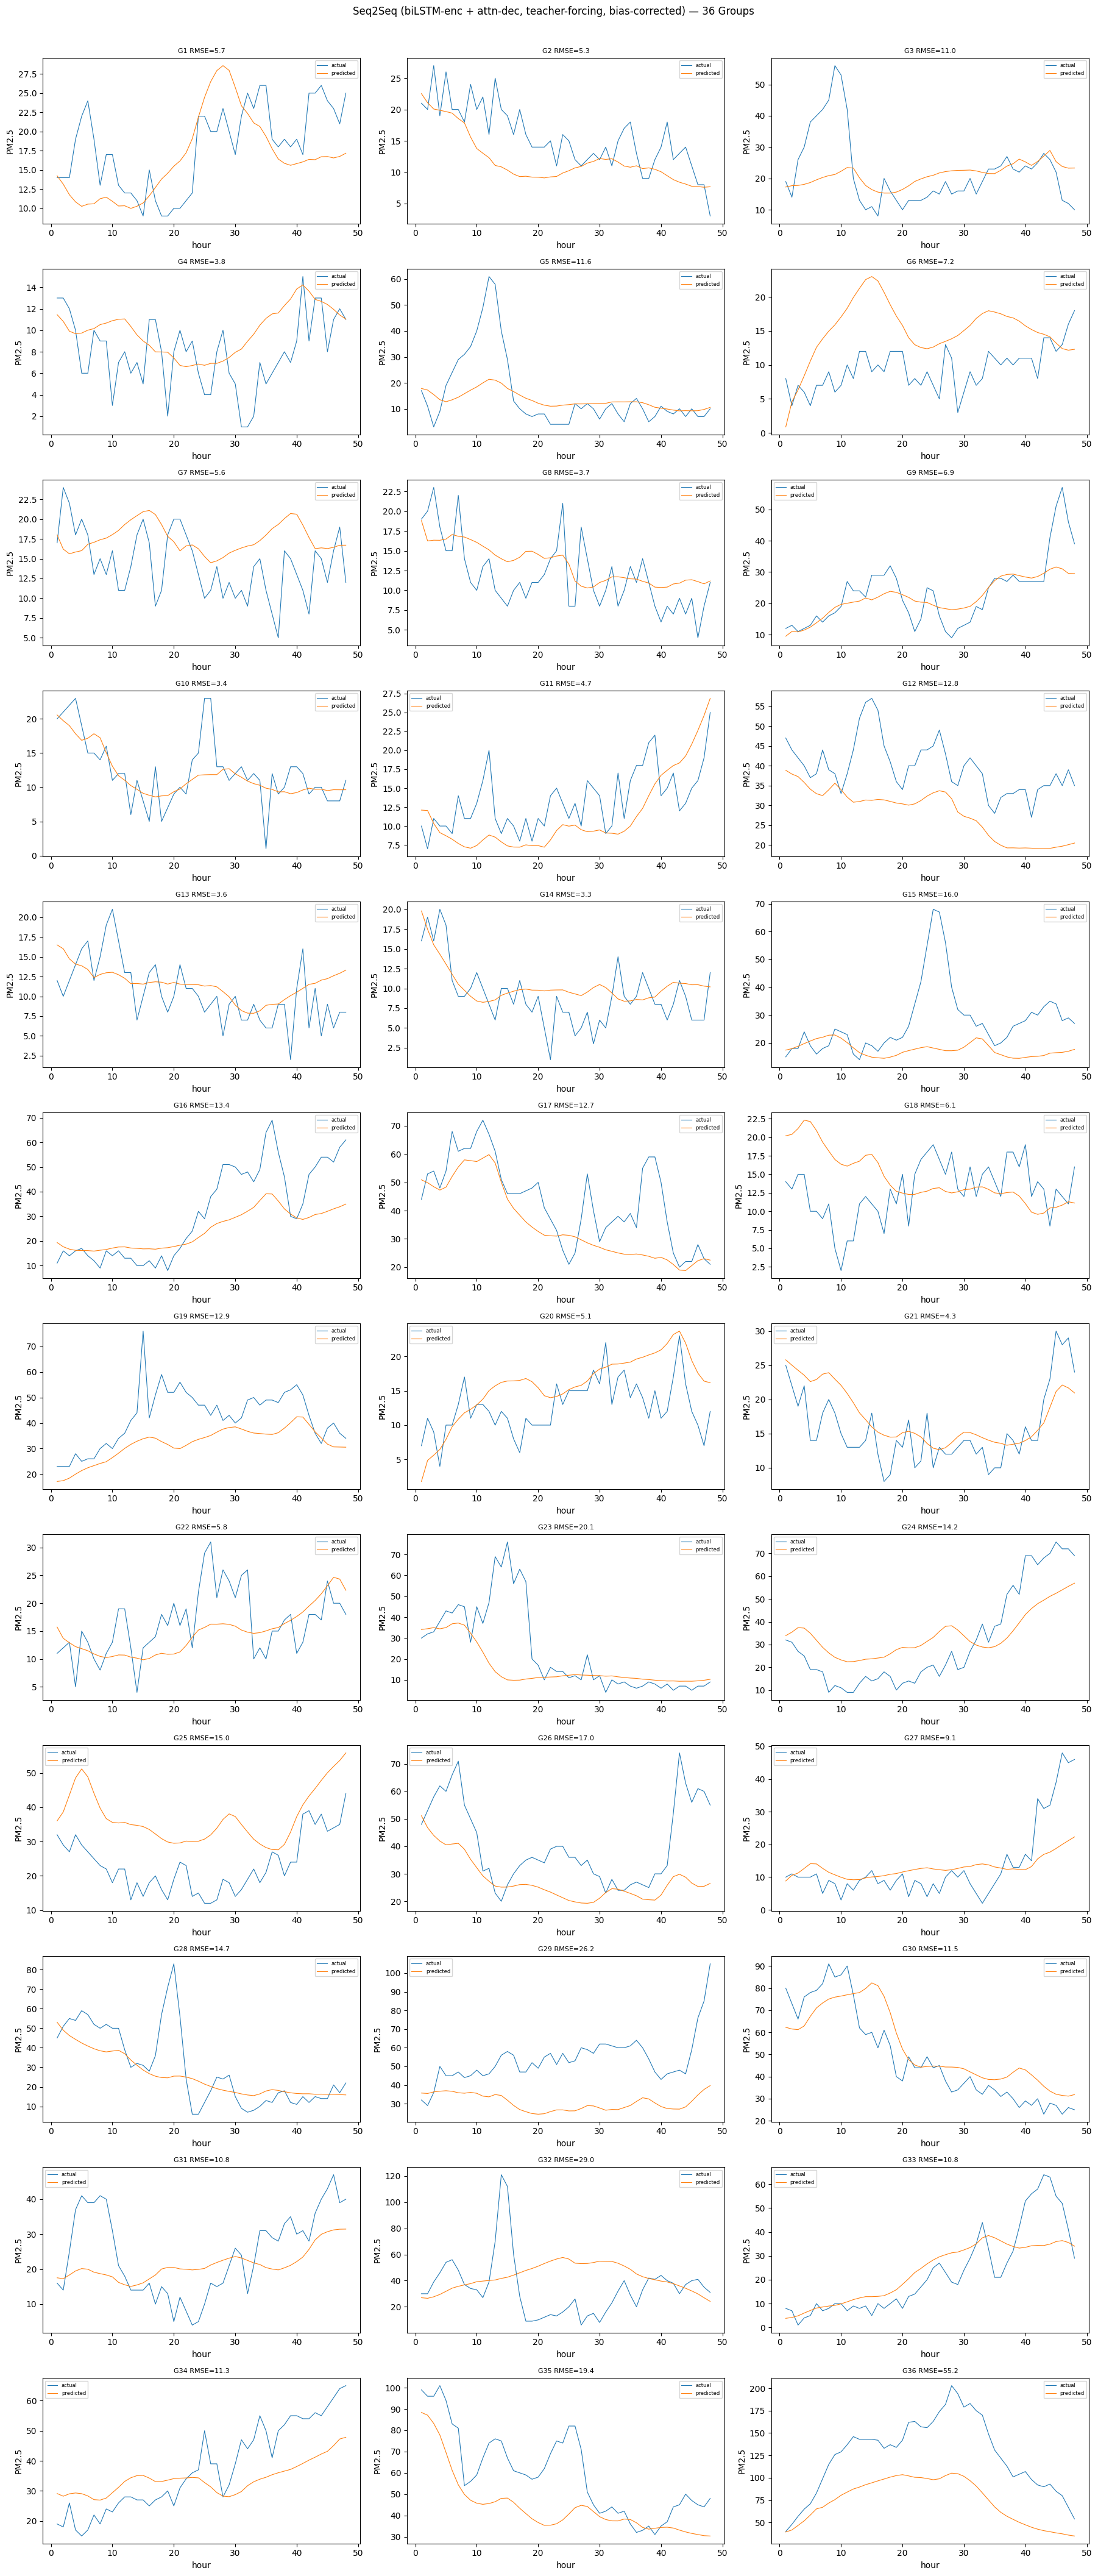

=== 分组平均 RMSE (既定基准) ===
  Seq2Seq       : 48h=11.92 | 24h=11.25
  持久性        : 48h=16.90 | 24h=13.55

=== 池化综合指标 (Seq2Seq) ===
  [48h] RMSE=15.30 MAE=9.52 FAC2=0.880 R=0.838 | 峰值(>75)n=69 RMSE=51.23 MAE=45.50
  [24h] RMSE=14.40 MAE=9.26 FAC2=0.873 R=0.853 | 峰值(>75)n=42 RMSE=40.38 MAE=34.67
=== 池化综合指标 (持久性) ===
  [48h] RMSE=23.11 MAE=14.15 FAC2=0.712 R=0.475 | 峰值(>75)n=69 RMSE=83.82 MAE=70.51
  [24h] RMSE=20.13 MAE=11.32 FAC2=0.806 R=0.628 | 峰值(>75)n=42 RMSE=73.10 MAE=59.69

=== 各组 RMSE(48h|24h) ===
  G 1:   5.74 |   5.69
  G 2:   5.25 |   6.44
  G 3:  10.96 |  14.42
  G 4:   3.75 |   3.20
  G 5:  11.58 |  16.02
  G 6:   7.15 |   7.94
  G 7:   5.59 |   4.99
  G 8:   3.72 |   4.02
  G 9:   6.94 |   4.56
  G10:   3.40 |   2.62
  G11:   4.66 |   4.36
  G12:  12.80 |  12.22
  G13:   3.58 |   3.32
  G14:   3.28 |   3.07
  G15:  16.00 |  10.25
  G16:  13.44 |   5.12
  G17:  12.73 |   8.33
  G18:   6.10 |   7.81
  G19:  12.89 |  15.61
  G20:   5.14 |   4.71
  G21:   4.35 |   5.04
  G22:   5.8

In [5]:
# ============================================================
# 评估: 36 组, 每组 168h 历史 → 一次预测 48h (seq2seq 自回归解码, 无 teacher forcing)
# 偏差校正减 α·bias_h; 截断[0, CLIP_HI]
# 指标: 分组平均 RMSE(48h|24h) + 池化(MAE/FAC2/R/峰值) + 持久性基线
# 画图: 12 行 × 3 列 = 36 张
# ============================================================
N_GROUPS, N_PRED = 36, 48
STRIDE = (len(df_te) - L - N_PRED) // (N_GROUPS - 1)
PEAK = 75.0

@torch.no_grad()
def predict_groups():
    P, A = [], []
    for g in range(N_GROUPS):
        T = g * STRIDE + L                            # 预测起点, 历史[T-L:T]用至T-1
        enc_x = torch.as_tensor(Fte[T-L:T]).float().unsqueeze(0).to(DEV)     # (1, L, 29)
        dec_w = torch.as_tensor(Fte[T:T+H, WIDX]).float().unsqueeze(0).to(DEV)  # (1, H, 9)
        pred = model(enc_x, dec_w, teacher_forcing_ratio=0.0).cpu().numpy().ravel()
        pred = pred * Y_STD + Y_MEAN - ALPHA * BIAS_H  # 反标准化 + 偏差校正
        P.append(np.clip(pred, 0, CLIP_HI)); A.append(np.expm1(df_te['pm_ave'].values[T:T+N_PRED]))
    return P, A

def persist_groups():
    P, A = [], []
    pm = np.expm1(df_te['pm_ave'].values)
    for g in range(N_GROUPS):
        T = g * STRIDE + L; P.append(np.full(N_PRED, pm[T-1])); A.append(pm[T:T+N_PRED])
    return P, A

def group_rmse(P, A, k=None):
    return float(np.mean([np.sqrt(((p[:k]-a[:k])**2).mean()) for p, a in zip(P, A)]))

def pooled(P, A, k, tag):
    p = np.concatenate([x[:k] for x in P]); a = np.concatenate([x[:k] for x in A])
    rmse = np.sqrt(((p-a)**2).mean()); mae = np.abs(p-a).mean()
    fac2 = np.mean((p/(a+1e-6) <= 2) & (a/(p+1e-6) <= 2)); r = np.corrcoef(p, a)[0,1]
    pk = a > PEAK
    prmse = np.sqrt(((p[pk]-a[pk])**2).mean()) if pk.sum() else float('nan')
    pmae = np.abs(p[pk]-a[pk]).mean() if pk.sum() else float('nan')
    print(f'  [{tag}] RMSE={rmse:.2f} MAE={mae:.2f} FAC2={fac2:.3f} R={r:.3f} | 峰值(>{PEAK:.0f})n={int(pk.sum())} RMSE={prmse:.2f} MAE={pmae:.2f}')

P, A = predict_groups()
rmses = [np.sqrt(((p-a)**2).mean()) for p, a in zip(P, A)]
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, A[g], lw=0.8, label='actual'); ax.plot(h, P[g], lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[g]:.1f}', fontsize=8)
    ax.legend(fontsize=6); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'Seq2Seq (biLSTM-enc + attn-dec, teacher-forcing, bias-corrected) — {N_GROUPS} Groups', fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

PP, AA = persist_groups()
print('=== 分组平均 RMSE (既定基准) ===')
print(f'  Seq2Seq       : 48h={group_rmse(P,A):.2f} | 24h={group_rmse(P,A,24):.2f}')
print(f'  持久性        : 48h={group_rmse(PP,AA):.2f} | 24h={group_rmse(PP,AA,24):.2f}')
print('\n=== 池化综合指标 (Seq2Seq) ===')
pooled(P, A, 48, '48h'); pooled(P, A, 24, '24h')
print('=== 池化综合指标 (持久性) ===')
pooled(PP, AA, 48, '48h'); pooled(PP, AA, 24, '24h')
print('\n=== 各组 RMSE(48h|24h) ===')
for g in range(N_GROUPS):
    r48 = np.sqrt(((P[g]-A[g])**2).mean()); r24 = np.sqrt(((P[g][:24]-A[g][:24])**2).mean())
    print(f'  G{g+1:2d}: {r48:6.2f} | {r24:6.2f}')